site 0: gamma = 4.741593
site 1: gamma = 1.633628
site 2: gamma = 1.633628
site 3: gamma = 1.633628
site 4: gamma = 1.633628
site 5: gamma = 1.633628
site 6: gamma = 1.633628
site 7: gamma = 1.633628
site 8: gamma = 1.633628
site 9: gamma = 1.633628
site 10: gamma = 1.633628
site 11: gamma = 1.633628
site 12: gamma = 1.633628
site 13: gamma = 1.633628
site 14: gamma = 1.633628


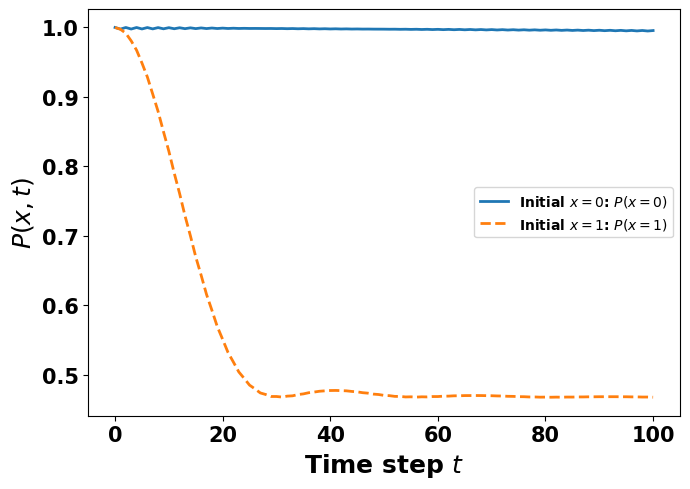

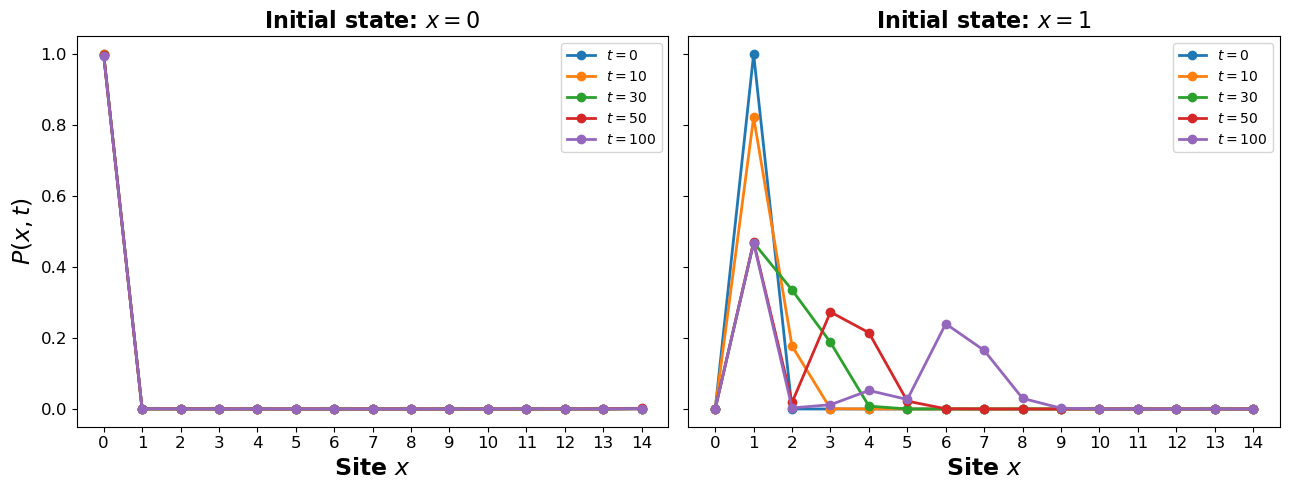

In [2]:
import numpy as np
import matplotlib.pyplot as mp

N = 100                  # number of time steps
P = 15                   # number of sites
T = 2

pi = np.pi

coin0 = np.array([1, 0], dtype=complex)
coin1 = np.array([0, 1], dtype=complex)

C00 = np.outer(coin0, coin0)
C01 = np.outer(coin0, coin1)
C10 = np.outer(coin1, coin0)
C11 = np.outer(coin1, coin1)


def topcoin(T, th):

    C = (
        np.cos(T*th/2) * C00
        - np.sin(T*th/2) * C01
        + np.sin(T*th/2) * C10
        + np.cos(T*th/2) * C11
    )

    return C


def initial_state(P, initial_site, l=np.pi/2, phi=0):

    # Position state
    pos = np.zeros(P, dtype=complex)
    pos[initial_site] = 1.0

    # Coin state
    coin_state = (
        np.cos(l/2) * coin0
        + np.exp(1j*phi) * np.sin(l/2) * coin1
    )

    # Full state
    psi0 = np.kron(pos, coin_state)

    return psi0

def build_shifts(P):

    out1 = np.zeros((P, P), dtype=complex)
    out2 = np.zeros((P, P), dtype=complex)

    for i in range(P):

        # shift -1
        j_minus = (i - 1) % P
        out1[j_minus, i] = 1.0

        # shift +1
        j_plus = (i + 1) % P
        out2[j_plus, i] = 1.0

    # Split-step shifts
    Splus = (
        np.kron(out2, C00)
        + np.kron(np.eye(P), C11)
    )

    Sminus = (
        np.kron(out1, C11)
        + np.kron(np.eye(P), C00)
    )

    return Splus, Sminus



def build_coin_operator(theta, P, T):

    C = np.zeros((2*P, 2*P), dtype=complex)

    for x in range(P):

        projector = np.zeros((P, P), dtype=complex)
        projector[x, x] = 1.0

        C += np.kron(
            projector,
            topcoin(T, theta[x])
        )

    return C


def build_floquet(theta):

    Splus, Sminus = build_shifts(P)

    C = build_coin_operator(theta, P, T)

    # SCSS-CQW Floquet operator
    U = Splus @ C @ Sminus @ C

    return U



def evolve(initial_site, U, N):

    psi = initial_state(P, initial_site)

    probabilities = np.zeros((N+1, P))

    # t = 0
    for x in range(P):

        probabilities[0, x] = (
            abs(psi[2*x])**2
            + abs(psi[2*x+1])**2
        )

   
    for t in range(1, N+1):

        psi = U @ psi

        for x in range(P):

            probabilities[t, x] = (
                abs(psi[2*x])**2
                + abs(psi[2*x+1])**2
            )

    return probabilities

gamma_A = pi+1.6
gamma_B = 0.52*pi

theta = np.array(
    [gamma_A]*1 +
    [gamma_B]*14,
    dtype=float
)

#print("\nCoin configuration:")
for x in range(P):
    print(f"site {x}: gamma = {theta[x]:.6f}")
#Evolution Operator
U = build_floquet(theta)
    
# ============================================================
# RUN 1: INITIAL STATE AT SITE 0
# ============================================================

prob_0 = evolve(
    initial_site=0,
    U=U,
    N=N
)

prob_1 = evolve(
    initial_site=1,
    U=U,
    N=N
)

time_steps = np.arange(N+1)

P0_from_0 = prob_0[:, 0]
P1_from_1 = prob_1[:, 1]


fig = mp.figure(figsize=(7,5))

mp.plot(
    time_steps,
    P0_from_0,
    linewidth=2,
    label=r'Initial $x=0$: $P(x=0)$'
)

mp.plot(
    time_steps,
    P1_from_1,
    linewidth=2,
    linestyle='--',
    label=r'Initial $x=1$: $P(x=1)$'
)

mp.xlabel(
    r'Time step $t$',
    fontsize=18,
    fontweight='bold'
)

mp.ylabel(
    r'$P(x,t)$',
    fontsize=18,
    fontweight='bold'
)

mp.xticks(
    fontsize=15,
    fontweight='bold'
)

mp.yticks(
    fontsize=15,
    fontweight='bold'
)

mp.legend(
    fontsize=13,
    prop={'weight':'bold'}
)

mp.tight_layout()
mp.show()


# ============================================================
# SPATIAL PROBABILITY DISTRIBUTIONS
# ============================================================

times_to_plot = [0, 10, 30, 50, 100]

fig, axes = mp.subplots(
    1, 2,
    figsize=(13,5),
    sharey=True
)

for t in times_to_plot:

    axes[0].plot(
        np.arange(P),
        prob_0[t],
        marker='o',
        linewidth=2,
        label=f'$t={t}$'
    )

axes[0].set_xlabel(
    r'Site $x$',
    fontsize=17,
    fontweight='bold'
)

axes[0].set_ylabel(
    r'$P(x,t)$',
    fontsize=17,
    fontweight='bold'
)

axes[0].set_title(
    r'Initial state: $x=0$',
    fontsize=16,
    fontweight='bold'
)

axes[0].set_xticks(np.arange(P))
axes[0].tick_params(
    axis='both',
    labelsize=12
)

axes[0].legend(
    fontsize=11,
    prop={'weight':'bold'}
)


for t in times_to_plot:

    axes[1].plot(
        np.arange(P),
        prob_1[t],
        marker='o',
        linewidth=2,
        label=f'$t={t}$'
    )

axes[1].set_xlabel(
    r'Site $x$',
    fontsize=17,
    fontweight='bold'
)

axes[1].set_title(
    r'Initial state: $x=1$',
    fontsize=16,
    fontweight='bold'
)

axes[1].set_xticks(np.arange(P))

axes[1].tick_params(
    axis='both',
    labelsize=12
)

axes[1].legend(
    fontsize=11,
    prop={'weight':'bold'}
)

mp.tight_layout()
mp.show()


simulation= 0
simulation= 1
simulation= 2
simulation= 3
simulation= 4
simulation= 5
simulation= 6
simulation= 7
simulation= 8
simulation= 9
simulation= 10
simulation= 11
simulation= 12
simulation= 13
simulation= 14
simulation= 15
simulation= 16
simulation= 17
simulation= 18
simulation= 19
simulation= 20
simulation= 21
simulation= 22
simulation= 23
simulation= 24
simulation= 25
simulation= 26
simulation= 27
simulation= 28
simulation= 29
simulation= 30
simulation= 31
simulation= 32
simulation= 33
simulation= 34
simulation= 35
simulation= 36
simulation= 37
simulation= 38
simulation= 39
simulation= 40
simulation= 41
simulation= 42
simulation= 43
simulation= 44
simulation= 45
simulation= 46
simulation= 47
simulation= 48
simulation= 49


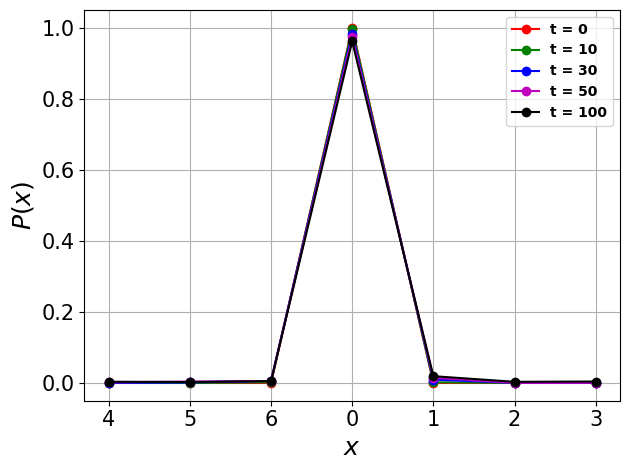

In [1]:
#Dynamic Coin disorder

from numpy import *

import numpy as np
import math
import random
from scipy import integrate
import matplotlib.pyplot as mp
#import time

N =100 #...number of random steps
P=7  #3     #sites of cyclic graphs
k1=P #no.of sites in the graph1

SHHH = np.zeros(N)   #...results to be stored in this array
simulations=50
# Pre-defs :
pi=np.pi
cos=np.cos
sin=np.sin
sqrt=np.sqrt
eye=np.eye
roll=np.roll
kron=np.kron
zeros=np.zeros
exp=np.exp
empty=np.empty
outer=np.outer
#sqrt=np.sqrt
#phi=pi/2
#l=0

#Needed stuffs :
coin0 = np.array([1, 0]) # |0>
coin1 = np.array([0, 1]) # |1>
C00 = np.outer(coin0, coin0) # |0><0|
C01 = np.outer(coin0, coin1) # |0><1|
C10 = np.outer(coin1, coin0) # |1><0|
C11 = np.outer(coin1, coin1) # |1><1|
def bcoin(T,th):
  gcoin = cos(T*th/2)*C00 - sin(T*th/2)*C01 + sin(T*th/2)*C10+cos(T*th/2)*C11
  return gcoin

def robtopcoin(T,th,w,d):  #for robustness with static/dyn coin disorders
  rth=th+w*d
  gcoin = cos(T*rth/2)*C00 - sin(T*rth/2)*C01 + sin(T*rth/2)*C10+cos(T*rth/2)*C11
  return gcoin

#ttotal = 0
w=0.01 #Here Din
T=2
jump=1
#----------------------------------------
def Schmidt(l, phi,P,out1,out2,th,randcoin,Splus,Sminus,T,w,Cb): #Calc Schmidt norm utpo steps N
        posn0 = zeros(P)
        posn0[0] = 1
        #l = random.randint(0, 180)
        #phi = random.randint(0, 360)
        psi0 = kron(posn0,(cos(l/2)*coin0 + exp(1j*phi)*sin(l/2)*coin1)) #kron(posn0,coin0) #
        psiN = psi0 # Initialisation
        #for i in range(1, m + 1):
            #psiN = np.linalg.matrix_power(DC,1).dot(psiN)
        #T=1
        for j in range(1, m + 1):
            dcoinn=0*kron(eye(P),eye(2))
            for i in range(0,P):
              dcoinn=dcoinn+kron(outer(eye(1,P,i),eye(1,P,i)),robtopcoin(T,th[i],w,randcoin[j-1]))
            DC=Splus.dot(dcoinn).dot(Sminus).dot(dcoinn) #S_hat.dot(dcoinn)
            psiN = np.linalg.matrix_power(DC,1).dot(psiN)
        psi_f=psiN
        #if m==2:
          #print("t=2:",psiN)
        #print("t=",m,psiN)
        hi=abs(psi_f[0])**2+abs(psi_f[1])**2
        return psi_f

#...Evaluation...:
def uniform_disorder(size, delta):
    return np.random.uniform(0, delta, size) #best to control disorder delta
#avg_pr=np.zeros(N+1)
Cb=kron(eye(P),bcoin(T,pi/2)) #coin b
out1=outer(zeros(k1),zeros(k1))
for i1 in range(0,k1):
  out1=out1+outer(eye(1,k1,np.mod(i1-jump,k1)),eye(1,k1,i1)) #jump1 here
out2=outer(zeros(k1),zeros(k1))
for i2 in range(0,k1):
  out2=out2+outer(eye(1,k1,np.mod(i2+jump,k1)),eye(1,k1,i2))  #jump1 here
Splus=kron(out2, C00)+kron(eye(P), C11)
Sminus=kron(out1, C11)+kron(eye(P), C00)
pro_avg= np.zeros((N + 1, P))

for simu in range(simulations):
  randcoin=pi*np.random.uniform(-1,1,N) #different coins to be used for different sites more like a stat coin disorder
  th=np.array([pi+1.6,0.52*pi,0.52*pi,0.52*pi,0.52*pi,0.52*pi,0.52*pi ])
  
  pro = np.zeros((N + 1, P))
  pro[0]=[1,0,0,0,0,0,0]   #0,0,0,0,0,0,0,0,0,0,0]
  for m in range(1,N+1):
    psi_f=Schmidt(pi/2, 0,P,out1,out2,th,randcoin,Splus,Sminus,T,w,Cb)
   
    prob_x = np.zeros(P)
    for site in range(P):
      prob_coin0 = abs(psi_f[2*site])**2
      prob_coin1 = abs(psi_f[2*site + 1])**2
      prob_x[site] = prob_coin0 + prob_coin1
    pro[m]=prob_x
  print("simulation=",simu)
  pro_avg=pro_avg+pro
pro_avg=pro_avg/simulations

# Plot: Probability vs x for selected times
times_to_plot = [0,10,30,50,100]  # Choose time steps you want to plot
colors = ['r', 'g', 'b', 'm', 'k']  # One color per time step

# This will force the *display order* of the x-axis to be 3,0,1,2 left to right
x_positions = [0, 1, 2, 3,4,5,6]               # Dummy positions: 0 to 3 (left to right)
x_labels    = ['4','5','6', '0', '1', '2','3']       # Custom tick labels in your desired order
x_order     = [4,5,6, 0, 1, 2,3]               # The *actual site indices* to access data

fig2 = mp.figure()
for idx, t in enumerate(times_to_plot):
    y = [pro_avg[t][i] for i in x_order]     # Order: 3 → 0 → 1 → 2
    mp.plot(x_positions, y, label=f't = {t}', color=colors[idx % len(colors)], marker='o')

mp.xticks(x_positions, x_labels)         # Show labels as 3, 0, 1, 2
mp.xlabel(r'$x$',fontsize=18, fontweight='bold')
mp.ylabel(r'$P(x)$',fontsize=18, fontweight='bold')
#mp.title('Probability vs Position for Different Times')
mp.yticks(fontsize=15)
mp.xticks(fontsize=15)
mp.legend(fontsize=15, loc='best', prop={'weight': 'bold'})
mp.grid(True)
mp.tight_layout()
#mp.savefig("trial-dyn005-SCSS-Edge-state-6pi4-3pi4-7cy-t2.pdf")
np.savetxt("dyn001_50.dat", pro_avg, fmt="%.8e")
mp.show() #START time